# DBSCAN Clustering on PeaksArray Data
## 1st and 2nd level clustering

This notebook covers DBSCAN clustering on the PeaksArray dataset obtained from the [Bragg Peaks and Centering notebook](https://github.com/2779765h/ACPP/blob/main/Notebooks/2%20-%20Bragg%20Peaks%20and%20Centering.ipynb).

DBSCAN clustering is applied as 1st level clustering, with suitable eps and scaling factors applied for the data. Cross plots as well as plots in both real and diffraction spaces are made. Then, 2nd level clustering is applied onto the centre of masses (COM) from the real space clusters.

By clustering on 4D vectors, in both real and diffraction spaces, clusters are formed based on the similarities between both spaces and therefore the COM clusters group together similar diffraction vectors which belong to the same crystal.

### Import packages and load PeaksArray

In [1]:
from sklearn.cluster import DBSCAN
from colorsys import hsv_to_rgb
import numpy as np
import matplotlib.pyplot as plt
import string
import py4DSTEM

C:\Users\alahe\anaconda3\envs\py4dstem\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
C:\Users\alahe\anaconda3\envs\py4dstem\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH

In [2]:
# Load Peaks Array
PeaksArray = np.load('data/PeaksArray_SmallRange.npy')

In [3]:
# Set same text size
plt.rcParams.update({'font.size': 14})

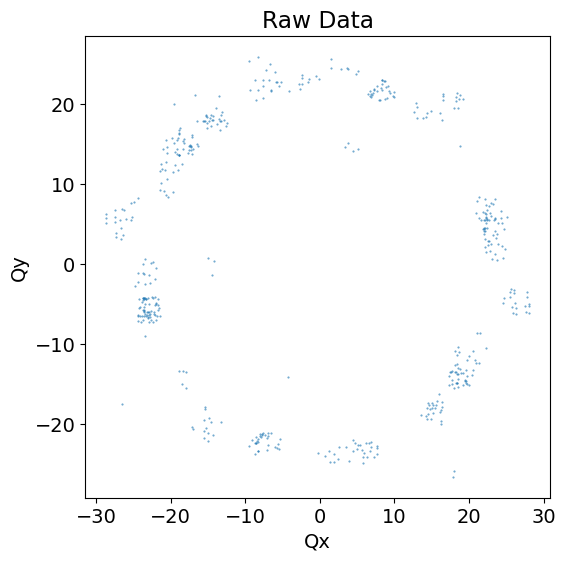

In [4]:
# Plot the data
plt.figure(figsize=[6,6])
plt.title('Raw Data')
plt.scatter(PeaksArray[:, 0], PeaksArray[:, 1], s=0.25, alpha=0.7)
plt.xlabel('Qx')
plt.ylabel('Qy')
plt.show()

## Applying DBSCAN Clustering

## Level 1 Clustering

This section involves applying DBSCAN onto the 4D vector (Qx, Qy, Rx, Ry) with selected eps, min_samples parameters and a scaling factor applied. A colour scheme is created for the clusters to allow for variety using HSV colours.

Then a range of cross plots, with different coordinates from each space, are plotted, and clusters are also shown in both real and diffraction spaces. 

DBSCAN plotting is also performed using the [DBScanClustering](https://github.com/2779765h/ACPP/blob/main/ProjectWork/BasicML/DBScanPlotting.py) function.

In [5]:
# DBScan Parameters
s = 0.4 
eps = 2
db1 = DBSCAN(eps=eps, min_samples=4).fit(PeaksArray[:,[0,1,3,4]]*np.array([1, 1, s, s])) 

In [6]:
# Colour Scheme
colours = []
r = db1.labels_.max()+1
d = 5
for n in range(r):
    h, v = int(n/d), n%d 
    H = h/(r/d)
    V = (4+v)/8
    S = 1
    c = hsv_to_rgb(H,S,V)
    colours += [c] 

### Clustering Plots

In [7]:
def DBScanClustering(Data, dblabels,
                     c1, c2, 
                     xlabel, ylabel, Title,
                     offset,
                     savefig = True):
    '''
    A function that plots a clustering graph from selected data arrays,
    after DBSCAN has been applied to a dataset. 
    
    Parameters
    ----------
    Data: numpy array
        dataset used for the DBSCAN algorithm
    dblabels: numpy array
        labels from dbscan clusters, i.e. db.labels_
    c1, c2: int
        column indices to select from the data array
    xlabel, ylabel: string
        labels for the x and y axes
    Title: string
        title for the plot
    offset: float
        offset can be used to adjust the spacing of labels from the data
    savefig: bool
        if True, the figure is saved as 'DBSCANClusteringPlot'

    Returns
    ----------
    None
    '''
    # Colour scheme
    colours = []
    r = dblabels.max()+1
    d = 5

    for n in range(r):
        h, v = int(n/d), n%d
        H = h/(r/d)
        V = (4+v)/8
        S = 1
        c = hsv_to_rgb(H,S,V)
        colours += [c] 
    
    # Plot
    fig, ax = plt.subplots(figsize=[8,8])
    ax.set_title(Title)

    for i in range(r):   
        Cluster = Data[np.where(dblabels == i)]
        scatter = ax.scatter(Cluster[:, c1], Cluster[:, c2], color=colours[i], label = i, s=5, alpha=1)
    
        for n in range(0,Cluster.shape[0],4500): # number of iterations 
            ax.text(
                Cluster[n, c1], 
                Cluster[n, c2]+offset, 
                int(i),
                horizontalalignment='center'
            )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    if savefig:
        plt.savefig('DBSCANClusteringPlot')

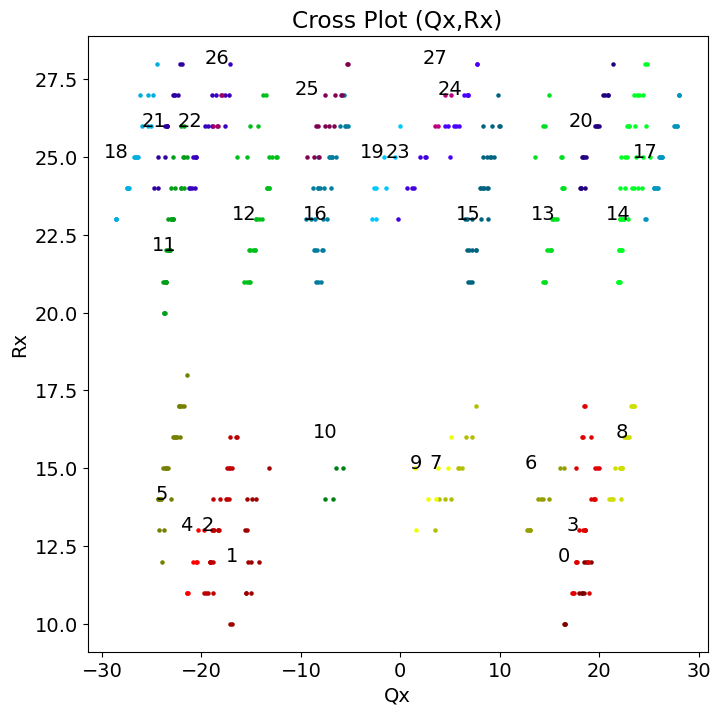

In [8]:
# Cross Plot (Qx, Rx)
DBScanClustering(PeaksArray, db1.labels_,
                     0, 3, 
                     'Qx', 'Rx', 'Cross Plot (Qx,Rx)',
                     2,
                     savefig = False)

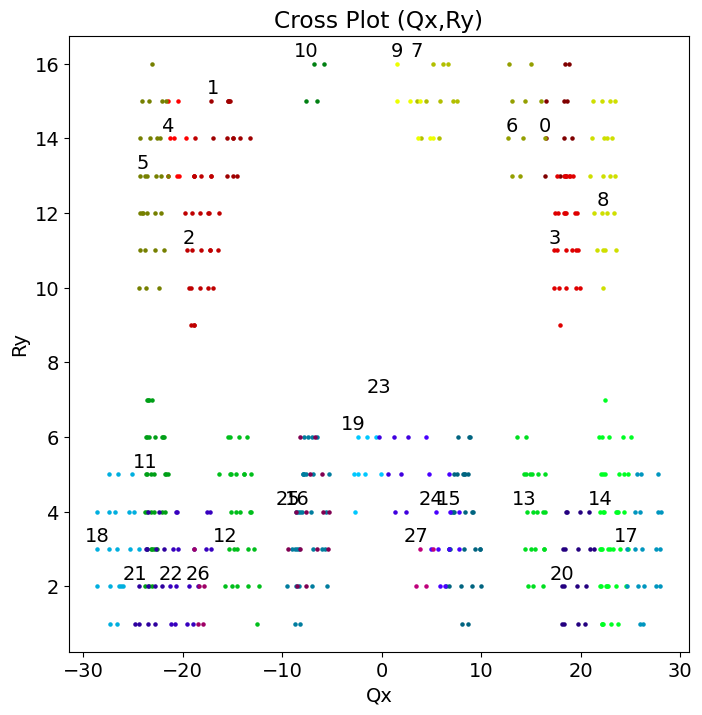

In [9]:
# Cross Plot (Qx,Ry)
DBScanClustering(PeaksArray, db1.labels_,
                     0, 4, 
                     'Qx', 'Ry', 'Cross Plot (Qx,Ry)',
                     1.2,
                     savefig = False)

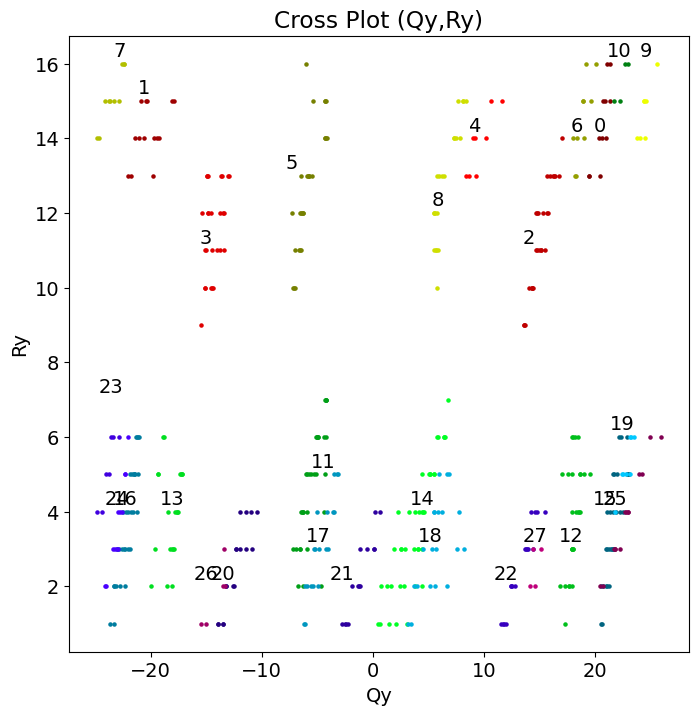

In [10]:
# Cross Plot (Qy,Ry)
DBScanClustering(PeaksArray, db1.labels_,
                     1, 4, 
                     'Qy', 'Ry', 'Cross Plot (Qy,Ry)',
                     1.2,
                     savefig = False)

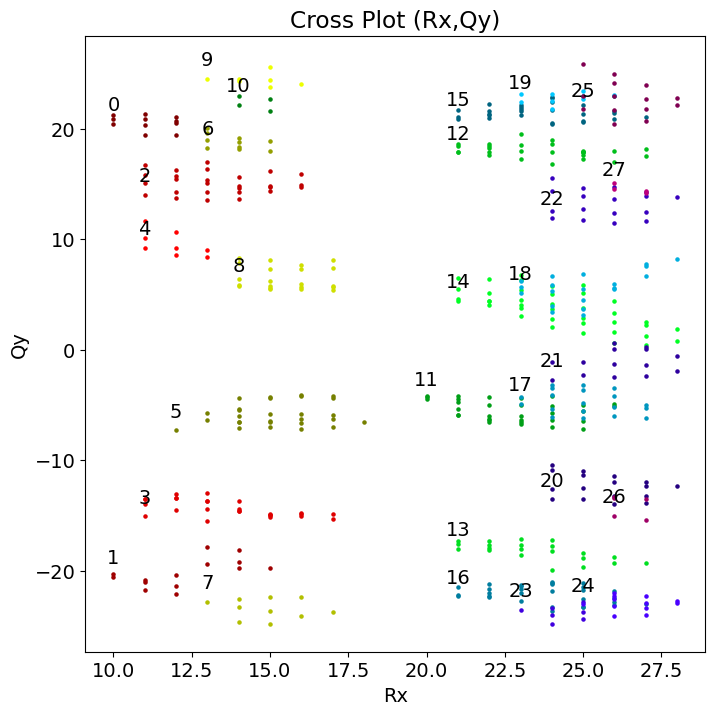

In [11]:
# Cross Plot (Rx,Qy)
DBScanClustering(PeaksArray, db1.labels_,
                     3, 1, 
                     'Rx', 'Qy', 'Cross Plot (Rx,Qy)',
                     1.2,
                     savefig = False)

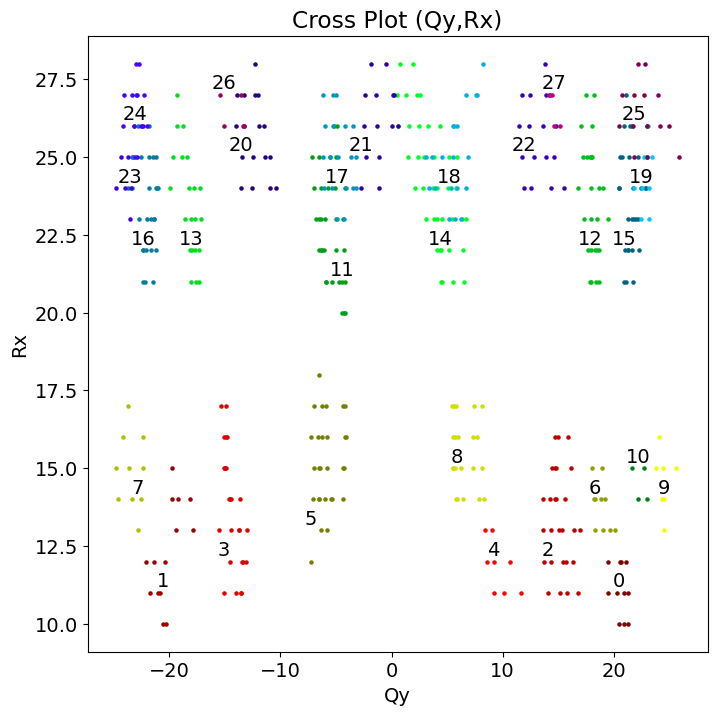

In [12]:
# Cross Plot (Qy,Rx)
DBScanClustering(PeaksArray, db1.labels_,
                     1, 3, 
                     'Qy', 'Rx', 'Cross Plot (Qy,Rx)',
                     1.2,
                     savefig = False)

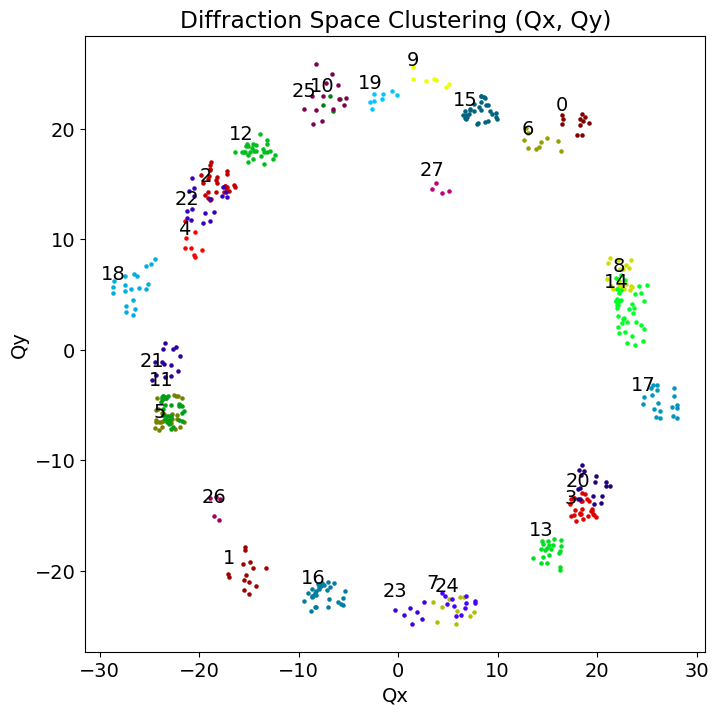

In [13]:
# Diffraction space (Qx, Qy)
DBScanClustering(PeaksArray, db1.labels_,
                     0, 1, 
                     'Qx', 'Qy', 'Diffraction Space Clustering (Qx, Qy)',
                     1.2,
                     savefig = False)

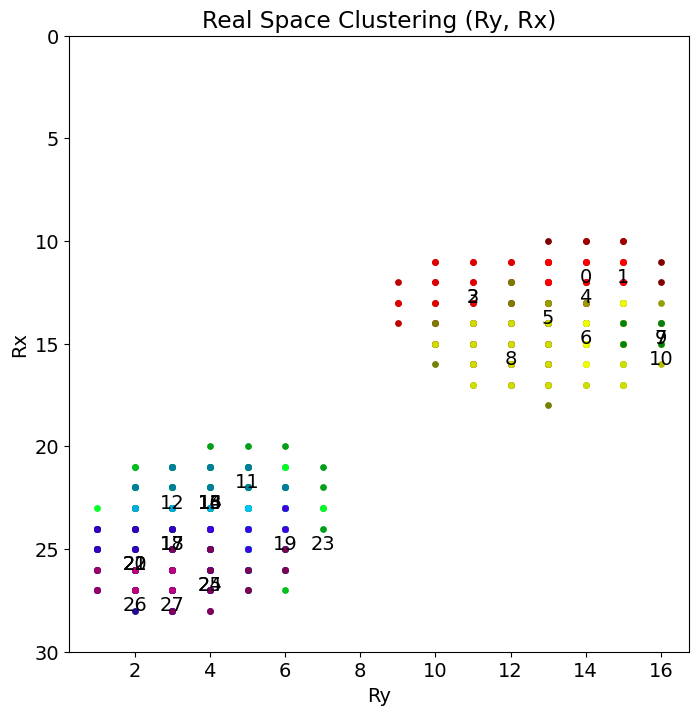

In [14]:
# Real space (Ry, Rx)
# Change ylim for comparison with later sections
plt.figure(figsize=[8,8])
plt.title('Real Space Clustering (Ry, Rx)')

for i in range(r):   
    Cluster = PeaksArray[np.where(db1.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 4], Cluster[:, 3], color = colours[i], label = i, s=15, alpha=1)
    
    for n in range(0,Cluster.shape[0],1000): # number of iterations 
        plt.text(
            Cluster[n, 4]+1, 
            Cluster[n, 3]+2, 
            int(i),
            horizontalalignment='center'
        )
plt.xlabel('Ry')
plt.ylabel('Rx')
plt.ylim(30,0)
plt.show()

## Centre of Mass (COM)

This section defines a function for computing the COM for each cluster in a clustering graph. For example, the COM is calculated for the real space coordinates. 

In [15]:
# find COM for each cluster
def COM_X(m,x):
    '''
    Calculates COM for x-coordinate.

    Data types:
    m: int or numpy array
    x: numpy array
    '''
    return (np.sum(m * x)) / np.sum(m)

def COM_Y(m,y):
    '''
    Calculates COM for y-coordinate.

    Data types:
    m: int or numpy array
    y: numpy array
    '''
    return (np.sum(m * y)) / np.sum(m)

def Cluster_COM(Data, Range, label, Weight=True):
    '''
    Calculates COM for every cluster in a clustering graph.
    
    Data types:
    Data: numpy array
    Range: numpy array
    label: numpy array
    Weight: bool
        if True, applies pixel weighting to the centre of masses

    '''
    COM_Values = []

    # loop over all clusters
    for p in Range:
        Cluster = Data[np.where(label == p)]

        if Weight:
            # COM weighting
            COM_Values.append((
                COM_X(Cluster[:,2], Cluster[:,3]),
                COM_Y(Cluster[:,2], Cluster[:,4])
            ))

        else:
            #COM no weighting
            COM_Values.append((
                COM_X(1, Cluster[:,3]),
                COM_Y(1, Cluster[:,4])
            ))
            
    return COM_Values

In [16]:
COM_Values = Cluster_COM(PeaksArray, np.arange(0, max(db1.labels_)+1,1), db1.labels_, Weight = True)

In [17]:
COM_Values = np.array(COM_Values)

## Level 2 Clustering (Clustering on COM)

After computing the COM we cluster on the COM in the real space coordinates. The level 2 clusters will contain several level 1 clusters. 

The eps and min_samples parameters are refined for the new COM dataset and the colour scheme redefined to run through the level 2 cluster labels and the clustering results are plotted for clustering analysis.

In [18]:
# Level 2 clustering on COM
db2 = DBSCAN(eps=1, min_samples=2).fit(COM_Values)

In [19]:
# Colour Scheme
colours = [] 
r = db2.labels_.max()+1 
d = 5
for n in range(r):
    h, v = int(n/d), n%d 
    H = h/(r/d)
    V = (4+v)/8
    S = 1
    c = hsv_to_rgb(H,S,V)
    colours += [c] 

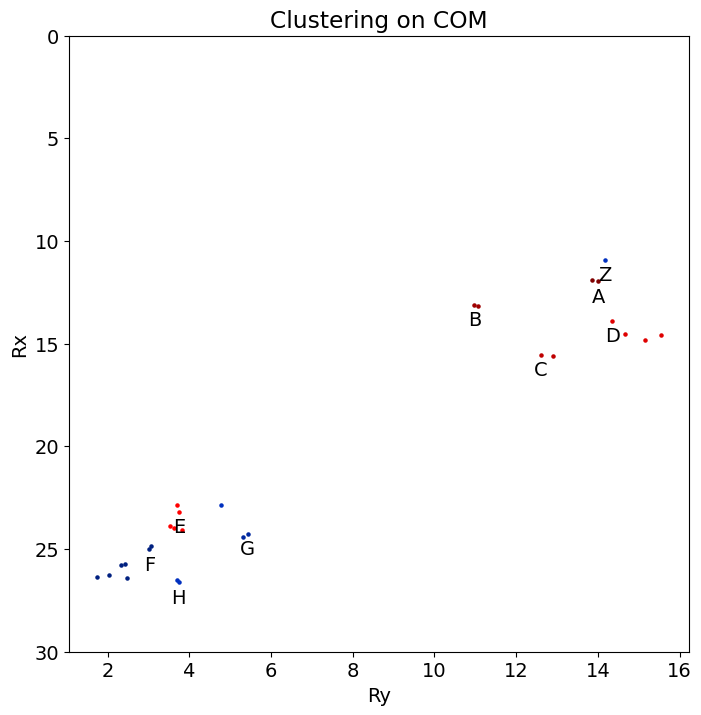

In [20]:
# Clustering in COM
# nearby clusters suggest diffraction vectors are from the same crystal
plt.figure(figsize=[8,8])
plt.title('Clustering on COM')

Text = string.ascii_uppercase
db2labels = np.unique(db2.labels_) 

for i in db2labels:
    Cluster = COM_Values[np.where(db2.labels_ == i)]
    scatter = plt.scatter(Cluster[:,1], Cluster[:,0], color = colours[i], label = i, s=5, alpha=1)

    for n in range(0,Cluster.shape[0],1000): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 0]+1, 
            str(Text[i]),
            horizontalalignment='center'
        )
plt.ylim(30,0)
plt.xlabel('Ry')
plt.ylabel('Rx')
plt.show()

### Save data

In [21]:
db1labels = (db1.labels_) 
db2labels =(db2.labels_) 
np.save('data/db1labels', db1labels)
np.save('data/COM_Values', COM_Values)
np.save('data/db2labels', db2labels)

## Digital Dark Field Images 

In [22]:
def VirtualImage(Data, Label, Index, savefig = True, figax = None):
    '''
    Function which produces the Digital Dark Field Image of a selected cluster.

    Data types:
    Data: numpy array
    Label: numpy array
        this corresponds to the clustering type, so for DBSCAN use db.labels_
        
    Index: Int
        select the index of the cluster
    figax: tuple, None
        (fig, ax)
    
    Return: 
    '''
    Cluster = Data[np.where(Label == Index)]

    Rxc = Cluster[:, 3]
    Ryc = Cluster[:, 4]

    # Finding max dimensions of Rx, Ry
    Rxmax, Rymax = Data[:,3].max().astype('int')+1, Data[:,4].max().astype('int')+1
    
    # Create image 
    image = np.zeros(shape=(Rxmax,Rymax))
    image[Rxc.astype('int'), Ryc.astype('int')]  = Cluster[:,2]

    # Plot
    if figax != None:
        fig, ax = figax
    else:
        fig, ax = plt.subplots(figsize=[7,7])

    ax.imshow(image)
      
    ax.set_xlabel('Ry')
    ax.set_ylabel('Rx')

    plt.show()
         
    if savefig:
        fig.savefig('DigitalDarkFieldImage')